# Module 03: Matplotlib for Machine Learning
## Notebook 01: Figure Anatomy and the Object-Oriented Interface

Data visualization is essential in every phase of the Machine Learning lifecycle: exploratory data analysis (EDA), diagnosing model training progress, evaluating prediction errors, and communicating insights. Matplotlib is Python's foundational plotting library upon which high-level libraries like Seaborn are built.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Explain the **Anatomy of a Figure** (Figure, Axes, Axis, Ticks, Spines).
2. Choose between the stateful `pyplot` interface and the industry-standard **Object-Oriented (OO)** interface.
3. Construct multi-metric line plots with custom styling, line widths, and markers.
4. Configure titles, axis labels, limits, grids, and multi-element legends.
5. Apply professional aesthetic principles to scientific charts.
6. **Advanced:** Construct dual-axis tracking graphs (`ax.twinx`), highlight early-stopping zones (`ax.axvspan`), and annotate critical inflection points (`ax.annotate`).

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure clean inline rendering and reproducible styling
plt.style.use('default')
print(f"Matplotlib successfully loaded!")

Matplotlib successfully loaded!


### 1. The Anatomy of a Figure

To master Matplotlib, you must understand its hierarchy:
- **`Figure`**: The top-level canvas containing everything (all plots, legends, titles, colorbars).
- **`Axes`**: An individual coordinate plane/plot area inside the Figure (a single Figure can contain multiple Axes).
- **`Axis`**: The number-line boundaries ($x$-axis, $y$-axis) controlling tick marks, tick labels, and limits.
- **`Spines`**: The four bounding box lines surrounding the Axes area.

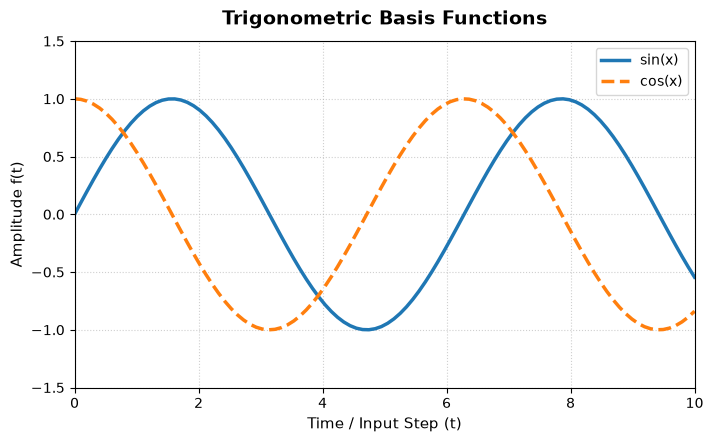

In [2]:
# Object-Oriented Figure and Axes instantiation
fig, ax = plt.subplots(figsize=(8, 4.5))

# Plotting on the Axes object
x = np.linspace(0, 10, 100)
ax.plot(x, np.sin(x), label='sin(x)', color='#1f77b4', linewidth=2.5)
ax.plot(x, np.cos(x), label='cos(x)', color='#ff7f0e', linewidth=2.5, linestyle='--')

# Setting labels and title via OO methods
ax.set_title("Trigonometric Basis Functions", fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel("Time / Input Step (t)", fontsize=11)
ax.set_ylabel("Amplitude f(t)", fontsize=11)
ax.set_xlim(0, 10)
ax.set_ylim(-1.5, 1.5)

# Styling grid and legend
ax.grid(True, linestyle=':', alpha=0.6)
ax.legend(loc='upper right', frameon=True)

plt.show()

---
### 2. Pyplot Interface vs. Object-Oriented Interface

> **Best Practice for Machine Learning:**
> - **Stateful Pyplot (`plt.plot`, `plt.title`)**: Implicitly tracks the "current active plot". Convenient for quick scratchpad checks, but becomes buggy and hard to manage with multi-panel dashboards or custom figure sizes.
> - **Object-Oriented (`fig, ax = plt.subplots()`)**: Explicitly exposes the `Figure` and `Axes` objects. **Always use the OO approach** for production, scientific reports, and complex ML dashboards!

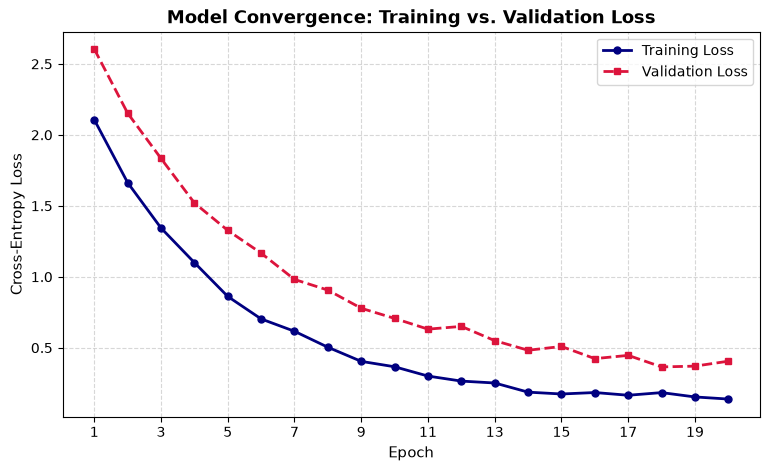

In [3]:
# Simulating training epochs and learning curves
epochs = np.arange(1, 21)
np.random.seed(42)
train_loss = 2.5 * np.exp(-0.25 * epochs) + 0.15 + np.random.normal(0, 0.02, size=len(epochs))
val_loss = 2.7 * np.exp(-0.20 * epochs) + 0.35 + np.random.normal(0, 0.03, size=len(epochs))

# Create Figure and Axes explicitly
fig, ax = plt.subplots(figsize=(9, 5))

# Plot training vs validation loss
ax.plot(epochs, train_loss, 'o-', color='navy', label='Training Loss', markersize=5, linewidth=2)
ax.plot(epochs, val_loss, 's--', color='crimson', label='Validation Loss', markersize=5, linewidth=2)

ax.set_title("Model Convergence: Training vs. Validation Loss", fontsize=13, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Cross-Entropy Loss", fontsize=11)
ax.set_xticks(np.arange(1, 21, 2))
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend(frameon=True, fontsize=10)

plt.show()

---
### 3. Advanced Complex Usage: Dual Y-Axes, Early-Stopping Zones, and Point Annotations

In production deep learning or gradient-boosted training:
1. **Dual Y-Axes (`ax.twinx()`):** Loss and Accuracy live on fundamentally different scales (e.g. $[0, 2.5]$ vs $[0.5, 1.0]$). A dual-axis plot maps both variables simultaneously across shared epoch steps.
2. **Span Highlighting (`ax.axvspan`):** Visually demarcates distinct training phases (e.g. warmup, optimal checkpoint, and overfitting regimes).
3. **Curved Vector Annotations (`ax.annotate` with `arrowprops`):** Dynamically spotlights the best checkpoint weight save.

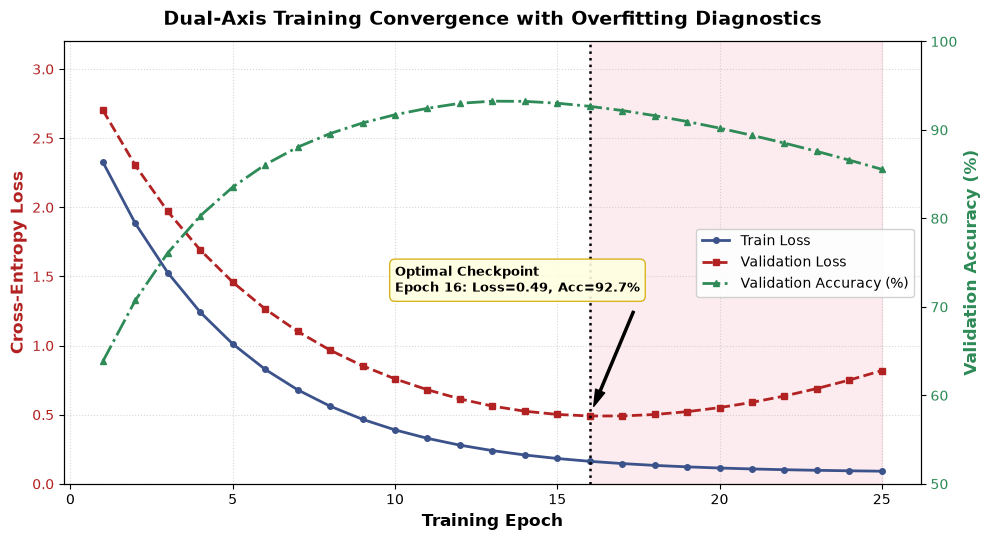

In [4]:
epochs = np.arange(1, 26)
train_loss = 2.8 * np.exp(-0.22 * epochs) + 0.08
val_loss = 2.9 * np.exp(-0.18 * epochs) + 0.28 + 0.003 * np.maximum(0, epochs - 12)**2
val_acc = 0.55 + 0.40 * (1 - np.exp(-0.25 * epochs)) - 0.002 * np.maximum(0, epochs - 12)**1.5

best_epoch = int(epochs[np.argmin(val_loss)])
best_val_loss = val_loss[best_epoch - 1]
best_val_acc = val_acc[best_epoch - 1]

fig, ax1 = plt.subplots(figsize=(10, 5.5))

# 1. Primary Y-Axis: Loss
color_loss = '#b22222'  # Firebrick
l1 = ax1.plot(epochs, train_loss, 'o-', color='#3b528b', label='Train Loss', linewidth=2, markersize=4)
l2 = ax1.plot(epochs, val_loss, 's--', color=color_loss, label='Validation Loss', linewidth=2, markersize=4)
ax1.set_xlabel("Training Epoch", fontsize=12, fontweight='bold')
ax1.set_ylabel("Cross-Entropy Loss", color=color_loss, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_loss)
ax1.set_ylim(0, 3.2)
ax1.grid(True, linestyle=':', alpha=0.5)

# 2. Secondary Y-Axis: Accuracy
ax2 = ax1.twinx()
color_acc = '#2e8b57'  # SeaGreen
l3 = ax2.plot(epochs, val_acc * 100, '^-.', color=color_acc, label='Validation Accuracy (%)', linewidth=2, markersize=5)
ax2.set_ylabel("Validation Accuracy (%)", color=color_acc, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_acc)
ax2.set_ylim(50, 100)

# 3. Demarcate Overfitting Zone with shaded span
ax1.axvspan(best_epoch, epochs[-1], color='crimson', alpha=0.08, label='Overfitting Zone')
ax1.axvline(best_epoch, color='black', linestyle=':', linewidth=1.8, label=f'Best Checkpoint (Epoch {best_epoch})')

# 4. Highlight best checkpoint with annotation arrow
ax1.annotate(
    f"Optimal Checkpoint\nEpoch {best_epoch}: Loss={best_val_loss:.2f}, Acc={best_val_acc*100:.1f}%",
    xy=(best_epoch, best_val_loss),
    xytext=(best_epoch - 6, best_val_loss + 0.9),
    arrowprops=dict(facecolor='black', edgecolor='black', width=1.5, headwidth=7, shrink=0.08),
    fontsize=9.5,
    fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffffe0', edgecolor='#d4ac0d', alpha=0.9)
)

# Combine legends across both twin axes
lines = l1 + l2 + l3
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='center right', framealpha=0.9)

ax1.set_title("Dual-Axis Training Convergence with Overfitting Diagnostics", fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- The hierarchical anatomy of Figures, Axes, and Axis components.
- The Object-Oriented interface for robust visualization workflows.
- Multi-curve line plotting, labeling, and axis styling.
- Dual y-axis architectures (`ax.twinx()`), shaded diagnostic spans (`ax.axvspan()`), and rich arrow annotations (`ax.annotate()`).

**Next Notebook:** `02_core_statistical_plots.ipynb` — Scatter plots with colormaps, bar charts, histograms, hexbin density maps, and box plots.